In [1]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [10]:
# ============================================================
# 1. Imports
# ============================================================
import json
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import keras_tuner as kt
import os

# ============================================================
# 2. Load Training Data
# ============================================================
with open('/content/train.json') as f:
    raw = json.load(f)

def build_story(item):
    return ' '.join([
        item.get('precontext',''),
        item.get('sentence',''),
        item.get('ending','')
    ])

def build_meaning(item):
    return item.get('judged_meaning','')

items    = list(raw.values())
stories  = [build_story(i) for i in items]
meanings = [build_meaning(i) for i in items]
labels   = np.array([i['average'] for i in items], dtype=np.float32)
stdevs   = np.array([i['stdev'] for i in items], dtype=np.float32)

# ============================================================
# 3. Tokenization
# ============================================================
MAX_WORDS = 10000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(stories + meanings)

X_story = pad_sequences(
    tokenizer.texts_to_sequences(stories),
    maxlen=MAX_LEN, padding='post'
)

X_mean = pad_sequences(
    tokenizer.texts_to_sequences(meanings),
    maxlen=MAX_LEN, padding='post'
)

Xs_train, Xs_val, Xm_train, Xm_val, y_train, y_val, s_train, s_val = train_test_split(
    X_story, X_mean, labels, stdevs,
    test_size=0.15, random_state=42
)

# ============================================================
# 4. Load GloVe Embeddings
# ============================================================
GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")

embeddings_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

word_index = tokenizer.word_index
num_words  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM))
for word, i in word_index.items():
    if i < num_words and word in embeddings_index:
        embedding_matrix[i] = embeddings_index[word]

# ============================================================
# 5. Attention Block
# ============================================================
def attention_block(x):
    scores = layers.Dense(1, activation='tanh')(x)
    weights = layers.Softmax(axis=1)(scores)
    return layers.Multiply()([x, weights])

# ============================================================
# 6. Encoder (BiSimpleRNN + Attention)
# ============================================================
def build_encoder(hp, name):
    rnn_units  = hp.Choice(f'{name}_rnn_units', [64, 128])
    num_layers = hp.Int(f'{name}_layers', 1, 2)
    dropout    = hp.Float(f'{name}_dropout', 0.2, 0.4, step=0.1)
    l2_reg     = hp.Choice(f'{name}_l2', [1e-4, 1e-3])

    inp = keras.Input(shape=(MAX_LEN,), name=f'{name}_input')

    x = layers.Embedding(
        num_words, EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    for _ in range(num_layers):
        x = layers.Bidirectional(
            layers.SimpleRNN(
                rnn_units,
                return_sequences=True,
                dropout=dropout,
                recurrent_dropout=0.1,
                kernel_regularizer=regularizers.l2(l2_reg)
            )
        )(x)

    x = attention_block(x)
    x = layers.GlobalAveragePooling1D()(x)

    return inp, x

# ============================================================
# 7. Dual-Encoder Comparison Model
# ============================================================
def build_model(hp):
    dense_units = hp.Choice('dense_units', [64, 128])
    lr          = hp.Choice('lr', [1e-3, 5e-4, 1e-4])

    story_inp, story_vec = build_encoder(hp, 'story')
    mean_inp, mean_vec  = build_encoder(hp, 'meaning')

    diff = layers.Lambda(lambda x: keras.backend.abs(x[0] - x[1]))(
        [story_vec, mean_vec]
    )

    combined = layers.Concatenate()([story_vec, mean_vec, diff])

    x = layers.Dense(dense_units, activation='relu')(combined)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='linear')(x)

    model = keras.Model([story_inp, mean_inp], out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# ============================================================
# 8. Hyperparameter Tuning
# ============================================================
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=12,
    directory='/content/tuner',
    project_name='ambistory_dual_encoder'
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

tuner.search(
    [Xs_train, Xm_train], y_train,
    validation_data=([Xs_val, Xm_val], y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_model = tuner.get_best_models(1)[0]
best_model.summary()

# ============================================================
# 9. Evaluation (SemEval Metrics)
# ============================================================
def evaluate(model, Xs, Xm, y, s):
    preds = np.clip(model.predict([Xs, Xm]).flatten(), 1, 5)
    s     = np.maximum(s, 1.0)

    print("Spearman r           :", spearmanr(y, preds).correlation)
    print("Accuracy within std  :", np.mean(np.abs(preds - y) <= s))
    return preds

print("\n── Validation Results ──")
val_preds = evaluate(best_model, Xs_val, Xm_val, y_val, s_val)

# ============================================================
# 10. Predict on Test Set
# ============================================================
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items = list(test_raw.values())
test_story = pad_sequences(
    tokenizer.texts_to_sequences([build_story(i) for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)
test_mean = pad_sequences(
    tokenizer.texts_to_sequences([build_meaning(i) for i in test_items]),
    maxlen=MAX_LEN, padding='post'
)

test_preds = np.clip(
    best_model.predict([test_story, test_mean]).flatten(),
    1, 5
)

print("\nSample Test Predictions:")
for i in range(min(10, len(test_preds))):
    print(f"Sample {i+1}: {test_preds[i]:.3f}")


Trial 12 Complete [00h 03m 53s]
val_mae: 1.053402066230774

Best val_mae So Far: 1.0419319868087769
Total elapsed time: 00h 17m 48s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ story_input         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meaning_input       │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 100)  │    492,300 │ story_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 150, 100)  │    492,300 │ meaning_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 150, 256)  │     58,624 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 150, 256)  │     58,624 │ embedding_1[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 150, 1)    │        257 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 150, 1)    │        257 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 150, 1)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 150, 1)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 150, 256)  │          0 │ bidirectional[0]… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 150, 256)  │          0 │ bidirectional_1[… │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256)       │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     49,216 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,151,643 (4.39 MB)

 Trainable params: 167,043 (652.51 KB)

 Non-trainable params: 984,600 (3.76 MB)


── Validation Results ──
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step
Spearman r           : 0.020714574767522375
Accuracy within std  : 0.5350877192982456
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Sample Test Predictions:
Sample 1: 3.076
Sample 2: 3.076
Sample 3: 3.076
Sample 4: 3.076
Sample 5: 3.076
Sample 6: 3.076
Sample 7: 3.078
Sample 8: 3.078
Sample 9: 3.078
Sample 10: 3.078


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Spearman r            : 0.0207
Accuracy within std   : 0.5351
Mean residual         : -0.0306


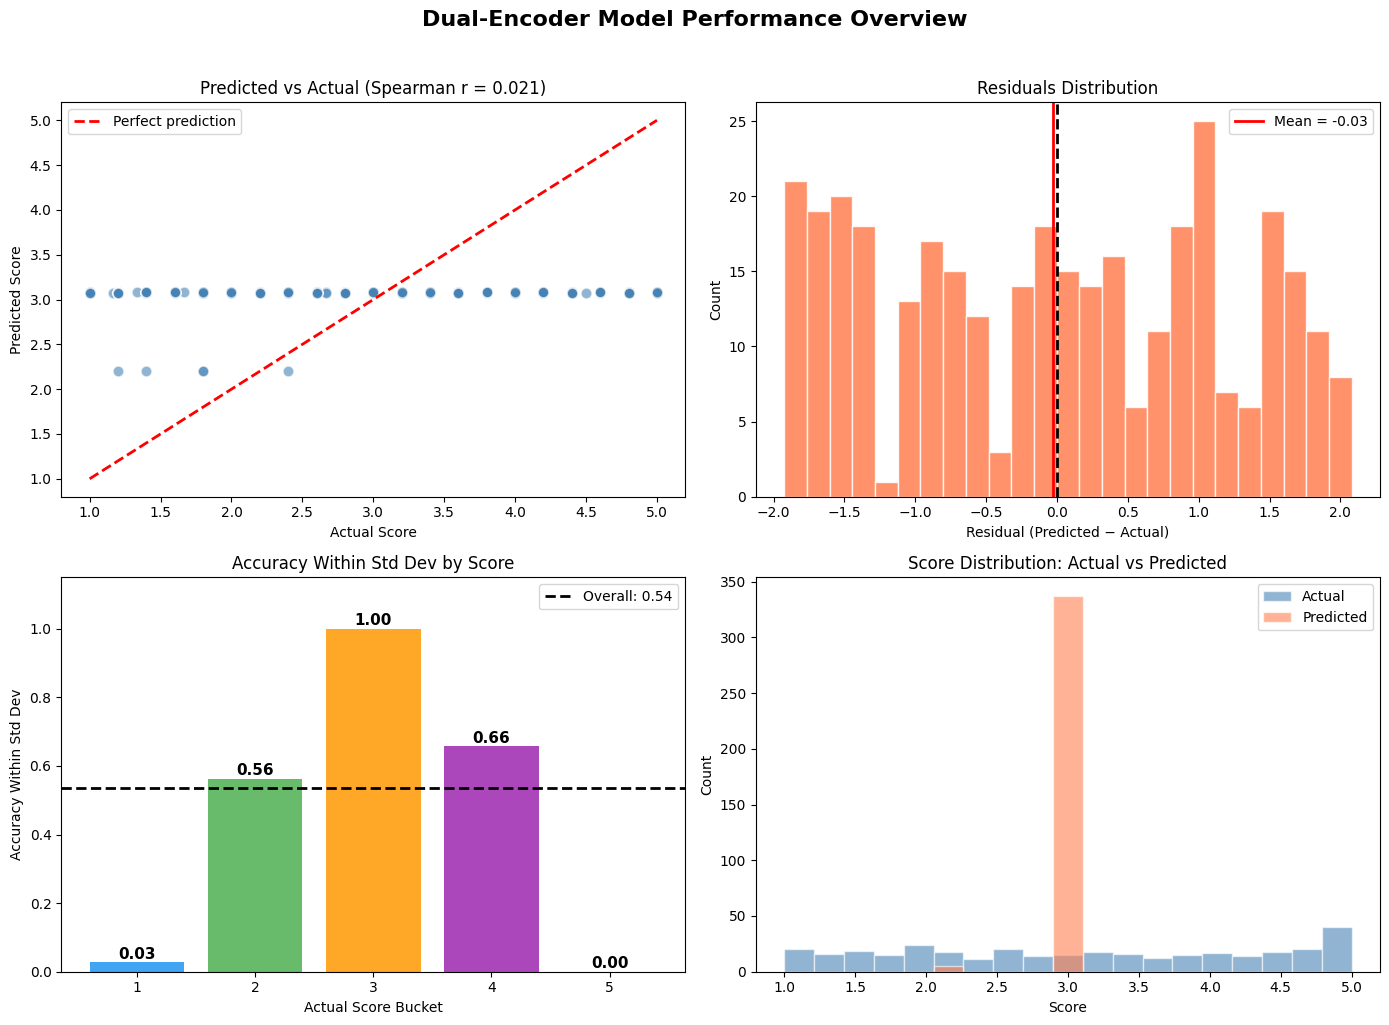

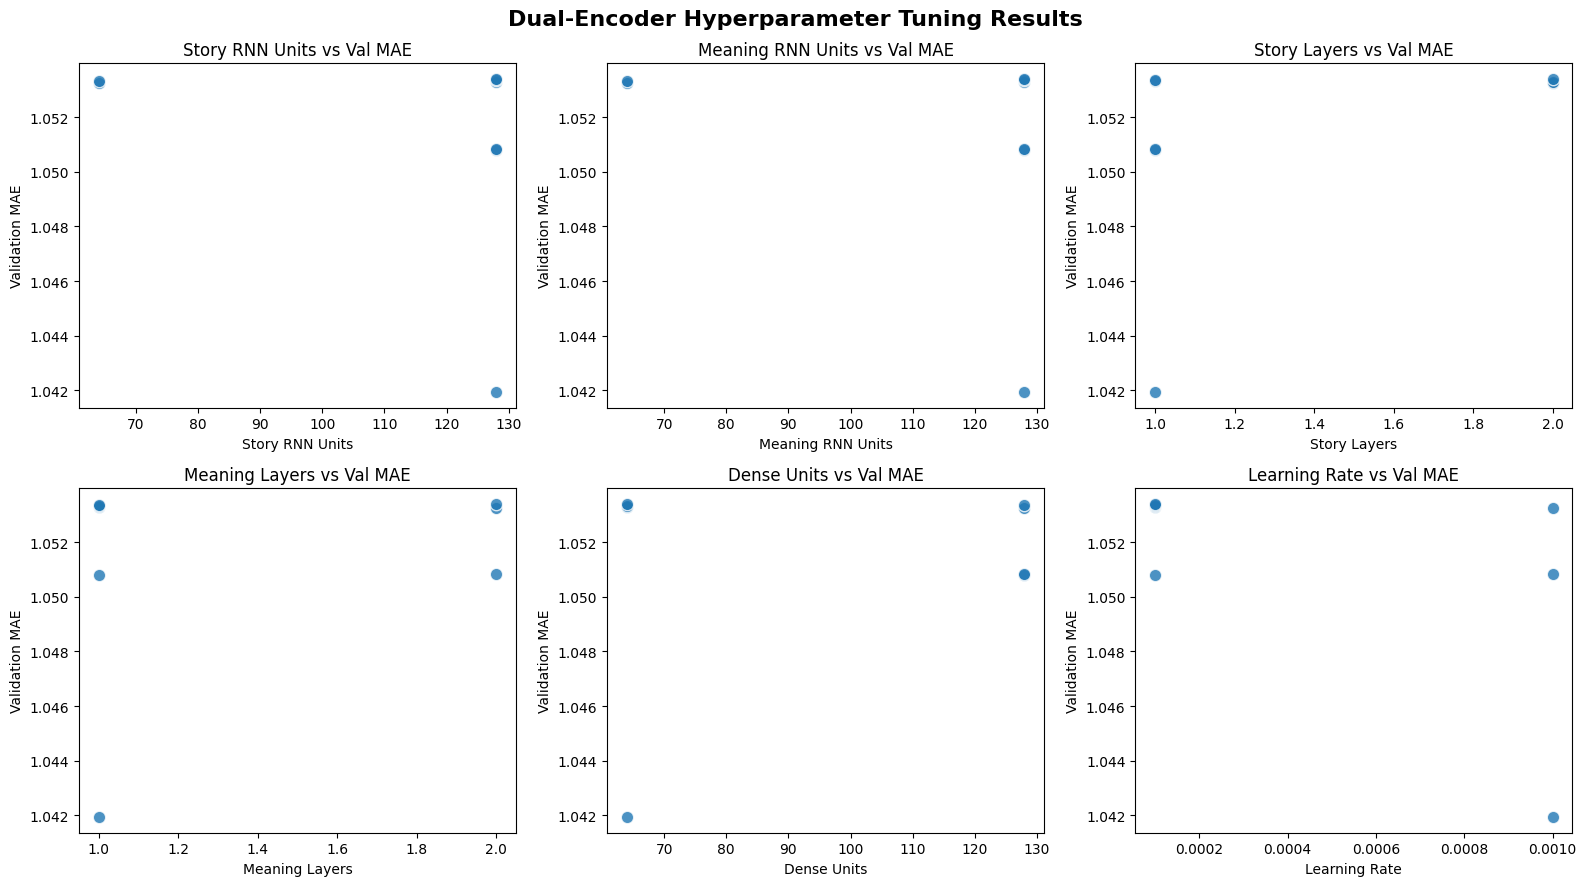

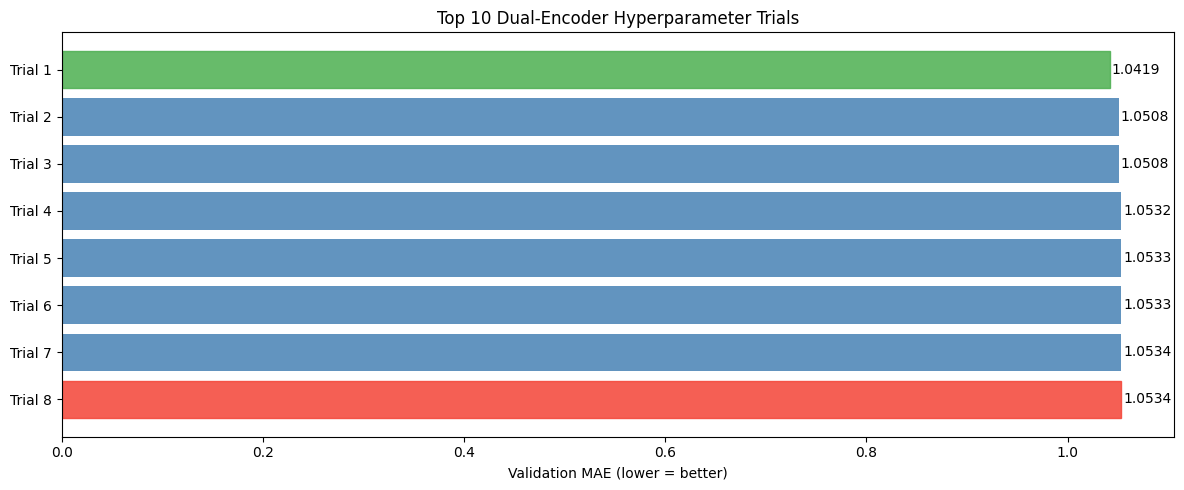

In [11]:
# ============================================================
# Dual-Encoder Visualization Script
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# ------------------------------------------------------------
# 1. Predictions & Metrics
# ------------------------------------------------------------
val_preds = np.clip(
    best_model.predict([Xs_val, Xm_val]).flatten(),
    1, 5
)

stdevs = np.maximum(s_val, 1.0)
within = np.abs(val_preds - y_val) <= stdevs
spear  = spearmanr(y_val, val_preds).correlation
residuals = val_preds - y_val

print(f"Spearman r            : {spear:.4f}")
print(f"Accuracy within std   : {within.mean():.4f}")
print(f"Mean residual         : {residuals.mean():.4f}")

# ------------------------------------------------------------
# 2. Collect Hyperparameter Tuning Results
# ------------------------------------------------------------
trial_data = []
for trial in tuner.oracle.trials.values():
    if trial.score is not None:
        hp = trial.hyperparameters.values
        trial_data.append({
            'val_mae'        : trial.score,
            'story_rnn'      : hp.get('story_rnn_units'),
            'meaning_rnn'    : hp.get('meaning_rnn_units'),
            'story_layers'   : hp.get('story_layers'),
            'meaning_layers' : hp.get('meaning_layers'),
            'dense_units'    : hp.get('dense_units'),
            'lr'             : hp.get('lr'),
        })

trial_data = sorted(trial_data, key=lambda x: x['val_mae'])

# ============================================================
# FIGURE 1 — Model Performance Overview
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dual-Encoder Model Performance Overview',
             fontsize=16, fontweight='bold', y=1.02)

# ------------------------------------------------------------
# 1. Predicted vs Actual
# ------------------------------------------------------------
ax = axes[0, 0]
ax.scatter(y_val, val_preds, alpha=0.6,
           color='steelblue', edgecolors='white', s=60)
ax.plot([1, 5], [1, 5], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title(f'Predicted vs Actual (Spearman r = {spear:.3f})')
ax.legend()
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0.8, 5.2)

# ------------------------------------------------------------
# 2. Residual Distribution
# ------------------------------------------------------------
ax = axes[0, 1]
ax.hist(residuals, bins=25, color='coral',
        edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red',
           linestyle='-', lw=2,
           label=f'Mean = {residuals.mean():.2f}')
ax.set_xlabel('Residual (Predicted − Actual)')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution')
ax.legend()

# ------------------------------------------------------------
# 3. Accuracy Within Std Dev by Score
# ------------------------------------------------------------
ax = axes[1, 0]
buckets = [1, 2, 3, 4, 5]
bucket_acc = []

for b in buckets:
    mask = (np.round(y_val) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)

bars = ax.bar(
    [str(b) for b in buckets], bucket_acc,
    color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
    alpha=0.85
)

ax.axhline(within.mean(), color='black',
           linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')

for bar, val in zip(bars, bucket_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.2f}', ha='center',
            fontsize=11, fontweight='bold')

ax.set_xlabel('Actual Score Bucket')
ax.set_ylabel('Accuracy Within Std Dev')
ax.set_title('Accuracy Within Std Dev by Score')
ax.set_ylim(0, 1.15)
ax.legend()

# ------------------------------------------------------------
# 4. Score Distribution
# ------------------------------------------------------------
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val, bins=bins, alpha=0.6,
        color='steelblue', label='Actual',
        edgecolor='white')
ax.hist(val_preds, bins=bins, alpha=0.6,
        color='coral', label='Predicted',
        edgecolor='white')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: Actual vs Predicted')
ax.legend()

plt.tight_layout()
plt.savefig('/content/dual_encoder_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2 — Hyperparameter Effects
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dual-Encoder Hyperparameter Tuning Results',
             fontsize=16, fontweight='bold')

params = [
    ('story_rnn', 'Story RNN Units'),
    ('meaning_rnn', 'Meaning RNN Units'),
    ('story_layers', 'Story Layers'),
    ('meaning_layers', 'Meaning Layers'),
    ('dense_units', 'Dense Units'),
    ('lr', 'Learning Rate')
]

for ax, (param, title) in zip(axes.flat, params):
    vals   = [t[param] for t in trial_data]
    scores = [t['val_mae'] for t in trial_data]
    ax.scatter(vals, scores, alpha=0.8,
               s=80, edgecolors='white')
    ax.set_xlabel(title)
    ax.set_ylabel('Validation MAE')
    ax.set_title(f'{title} vs Val MAE')

plt.tight_layout()
plt.savefig('/content/dual_encoder_hyperparams.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3 — Top 10 Trials
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
top10 = trial_data[:10]
labels = [f"Trial {i+1}" for i in range(len(top10))]
maes   = [t['val_mae'] for t in top10]

bars = ax.barh(labels[::-1], maes[::-1],
               color='steelblue', alpha=0.85)

bars[-1].set_color('#4CAF50')  # best
bars[0].set_color('#F44336')   # worst

for bar, val in zip(bars, maes[::-1]):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center')

ax.set_xlabel('Validation MAE (lower = better)')
ax.set_title('Top 10 Dual-Encoder Hyperparameter Trials')

plt.tight_layout()
plt.savefig('/content/dual_encoder_top10.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [8]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip


--2026-02-18 19:12:19--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-18 19:12:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-18 19:12:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov